In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("compas-scores-two-years.csv")

In [3]:
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [4]:
df = df[
    (df["days_b_screening_arrest"] <= 30) &
    (df["days_b_screening_arrest"] >= -30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].reset_index(drop=True)

features = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count", "c_charge_degree", "sex", "race"]
target = "two_year_recid"

df = df[features + [target, "decile_score", "score_text", "age_cat"]]
df.head()

,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,sex,race,two_year_recid,decile_score,score_text,age_cat
0,69,0,0,0,0,F,Male,Other,0,1,Low,Greater than 45
1,34,0,0,0,0,F,Male,African-American,1,3,Low,25 - 45
2,24,4,0,0,1,F,Male,African-American,1,4,Low,Less than 25
3,44,0,0,0,0,M,Male,Other,0,1,Low,25 - 45
4,41,14,0,0,0,F,Male,Caucasian,1,6,Medium,25 - 45


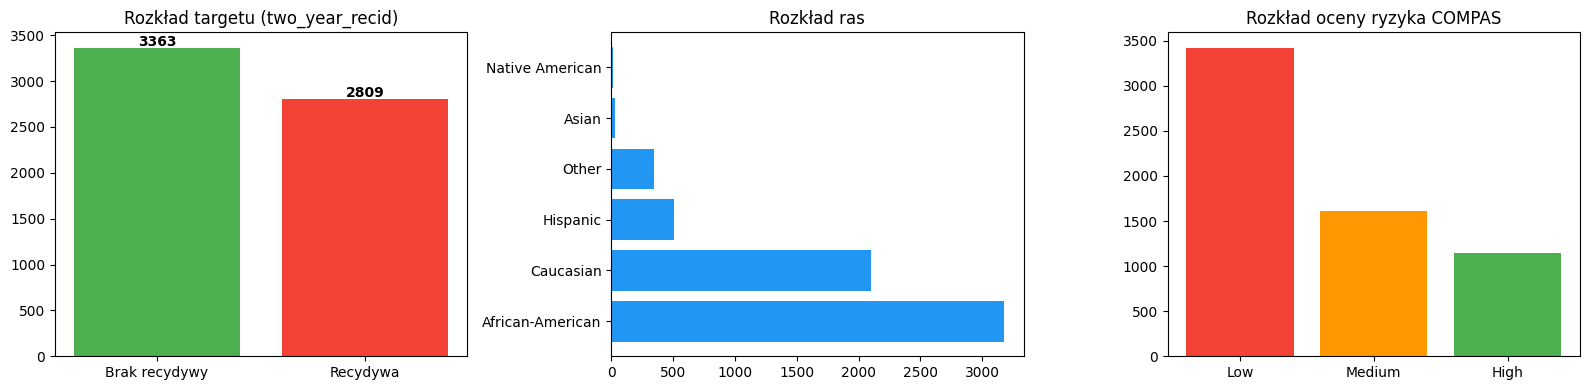

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df[target].value_counts()
axes[0].bar(["Brak recydywy", "Recydywa"], counts.values, color=["#4CAF50", "#F44336"])
axes[0].set_title("Rozkład targetu (two_year_recid)")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

race_counts = df["race"].value_counts()
axes[1].barh(race_counts.index, race_counts.values, color="#2196F3")
axes[1].set_title("Rozkład ras")

score_counts = df["score_text"].value_counts()
axes[2].bar(score_counts.index, score_counts.values, color=["#F44336", "#FF9800", "#4CAF50"])
axes[2].set_title("Rozkład oceny ryzyka COMPAS")

plt.tight_layout()
plt.show()

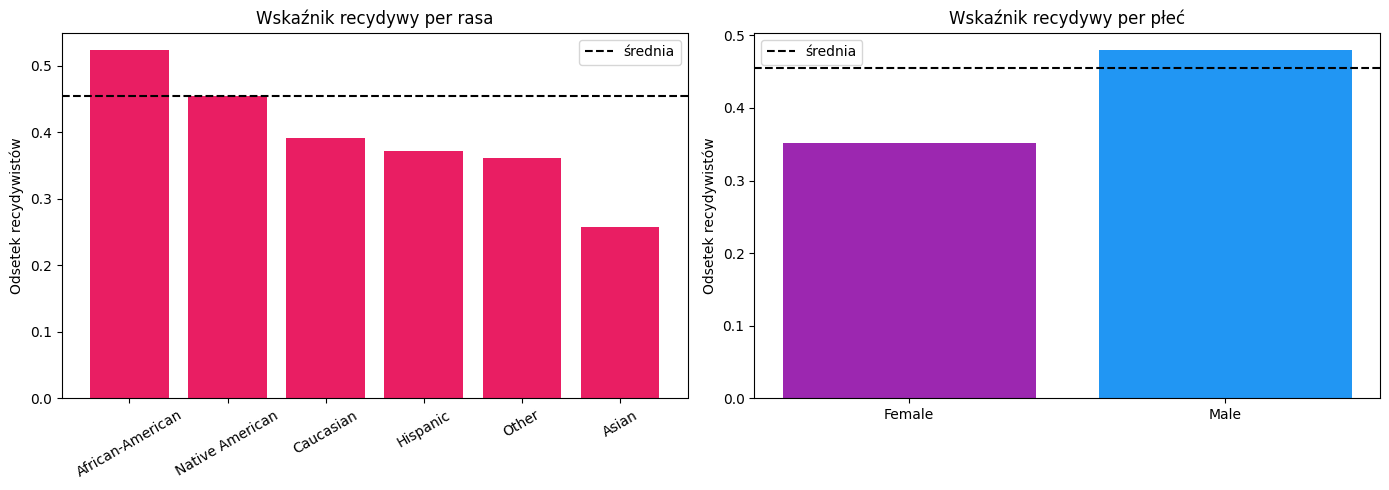

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

race_recid = df.groupby("race")[target].mean().sort_values(ascending=False)
axes[0].bar(race_recid.index, race_recid.values, color="#E91E63")
axes[0].set_title("Wskaźnik recydywy per rasa")
axes[0].set_ylabel("Odsetek recydywistów")
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(df[target].mean(), color="black", linestyle="--", label="średnia")
axes[0].legend()

sex_recid = df.groupby("sex")[target].mean()
axes[1].bar(sex_recid.index, sex_recid.values, color=["#9C27B0", "#2196F3"])
axes[1].set_title("Wskaźnik recydywy per płeć")
axes[1].set_ylabel("Odsetek recydywistów")
axes[1].axhline(df[target].mean(), color="black", linestyle="--", label="średnia")
axes[1].legend()

plt.tight_layout()
plt.show()

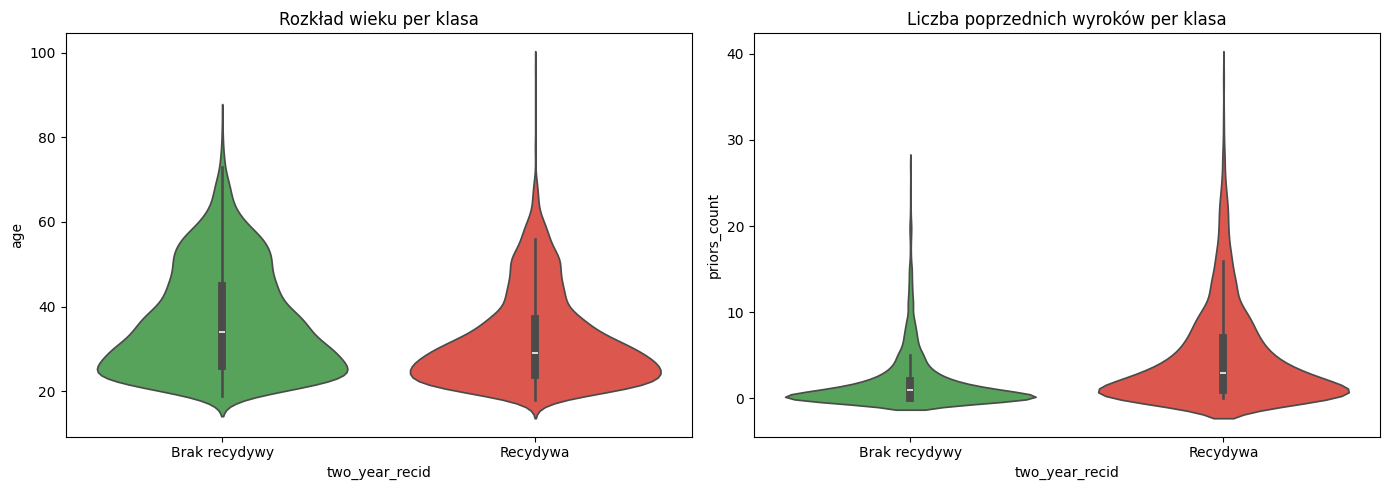

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x=target, y="age", hue=target, ax=axes[0],
               palette=["#4CAF50", "#F44336"], legend=False)
axes[0].set_title("Rozkład wieku per klasa")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Brak recydywy", "Recydywa"])

sns.violinplot(data=df, x=target, y="priors_count", hue=target, ax=axes[1],
               palette=["#4CAF50", "#F44336"], legend=False)
axes[1].set_title("Liczba poprzednich wyroków per klasa")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Brak recydywy", "Recydywa"])

plt.tight_layout()
plt.show()

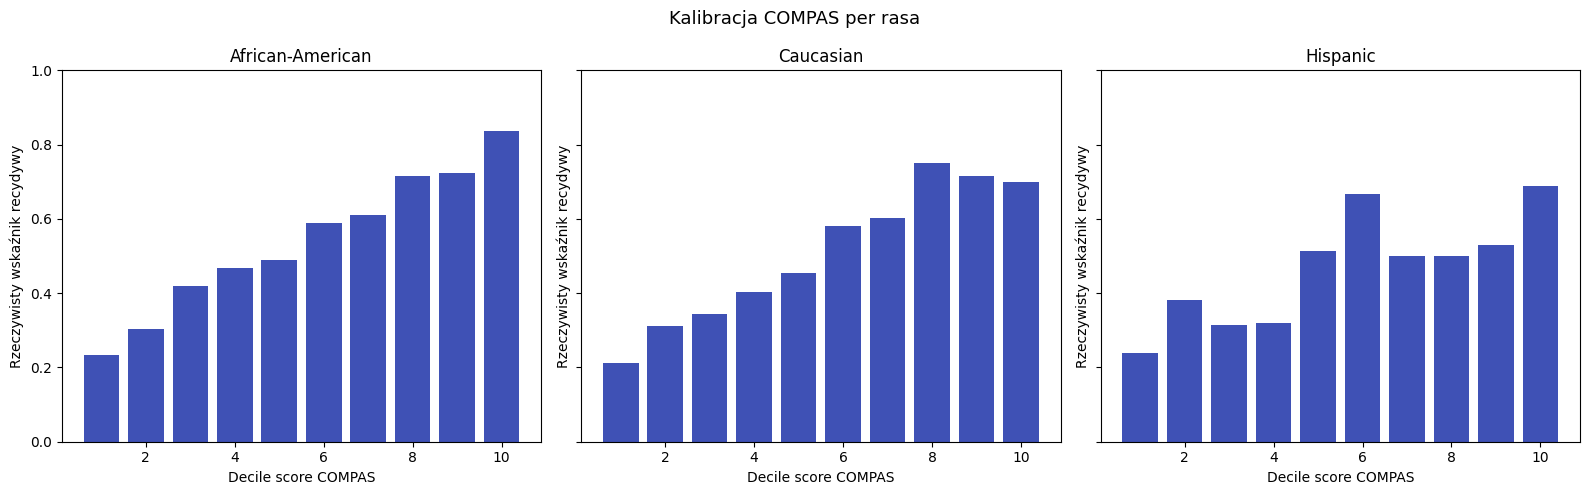

In [9]:
top_races = ["African-American", "Caucasian", "Hispanic"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, race in zip(axes, top_races):
    sub = df[df["race"] == race]
    recid_rate = sub.groupby("decile_score")[target].mean()
    ax.bar(recid_rate.index, recid_rate.values, color="#3F51B5")
    ax.set_title(race)
    ax.set_xlabel("Decile score COMPAS")
    ax.set_ylabel("Rzeczywisty wskaźnik recydywy")
    ax.set_ylim(0, 1)

plt.suptitle("Kalibracja COMPAS per rasa", fontsize=13)
plt.tight_layout()
plt.show()

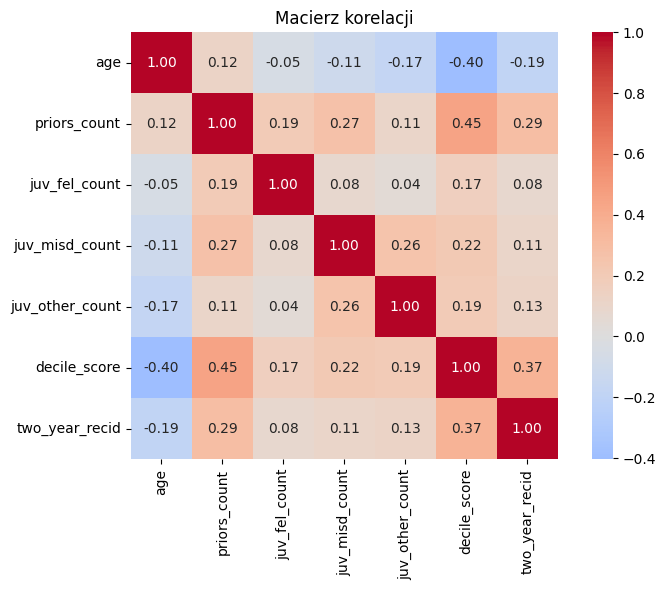

In [10]:
num_cols = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count", "decile_score", target]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Macierz korelacji")
plt.tight_layout()
plt.show()

In [11]:
le_sex = LabelEncoder()
le_charge = LabelEncoder()

df_model = df.copy()
df_model["sex"] = le_sex.fit_transform(df["sex"])
df_model["c_charge_degree"] = le_charge.fit_transform(df["c_charge_degree"])
df_model = pd.get_dummies(df_model, columns=["race", "age_cat"])

feature_cols = [c for c in df_model.columns if c not in [target, "decile_score", "score_text"]]

X = df_model[feature_cols].values
y = df_model[target].values

print(f"Wymiary: X={X.shape}, pozytywnych: {y.mean():.1%}")

Wymiary: X=(6172, 16), pozytywnych: 45.5%


___

In [15]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

glass = fetch_openml(name="glass", version=1, as_frame=True)
X_glass = glass.data.values
y_glass = LabelEncoder().fit_transform(glass.target)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost":      AdaBoostClassifier(n_estimators=100),
    "XGBoost":       XGBClassifier(n_estimators=100, verbosity=0, eval_metric="mlogloss"),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_glass, y_glass, cv=5, scoring="f1_macro")
    results[name] = scores

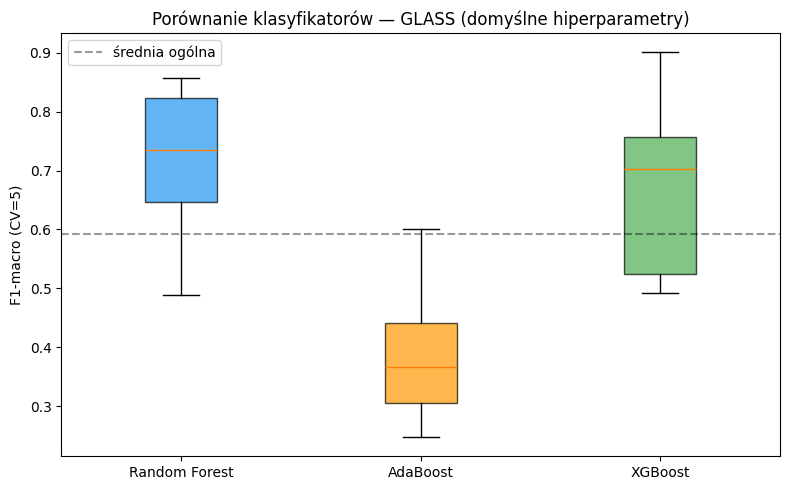

Random Forest: 0.710 ± 0.133
AdaBoost: 0.393 ± 0.123
XGBoost: 0.675 ± 0.152


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(results.values(), labels=results.keys(), patch_artist=True)
colors = ["#2196F3", "#FF9800", "#4CAF50"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("F1-macro (CV=5)")
ax.set_title("Porównanie klasyfikatorów — GLASS (domyślne hiperparametry)")
ax.axhline(np.mean(list(results.values())), color="black", linestyle="--", alpha=0.4, label="średnia ogólna")
ax.legend()
plt.tight_layout()
plt.show()

for name, scores in results.items():
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

___

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import itertools

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

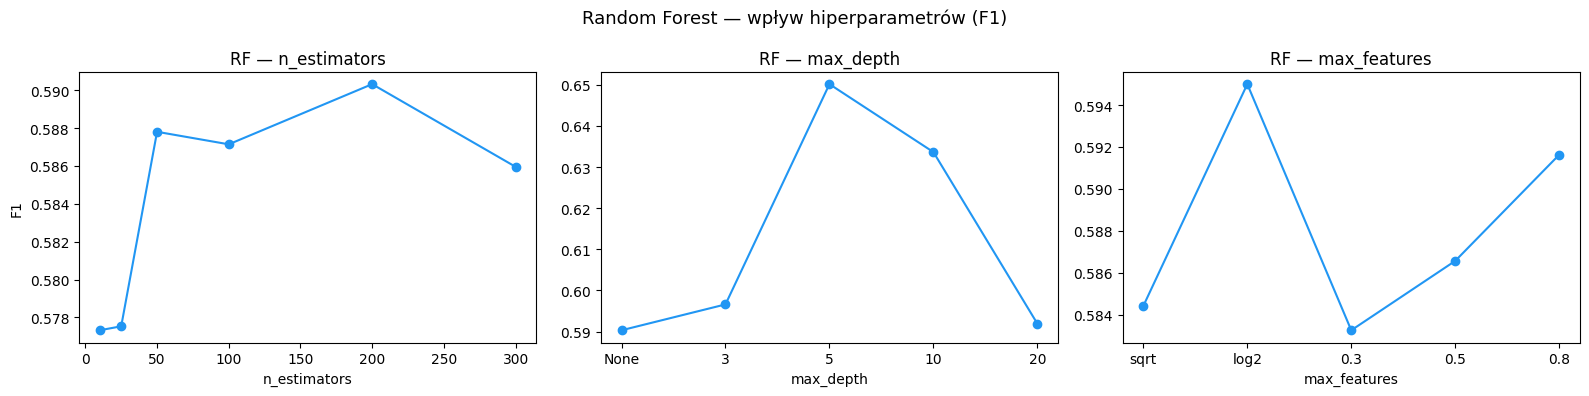

In [18]:
n_estimators_vals = [10, 25, 50, 100, 200, 300]
max_depth_vals    = [None, 3, 5, 10, 20]
max_features_vals = ["sqrt", "log2", 0.3, 0.5, 0.8]

rf_nest = []
for n in n_estimators_vals:
    m = RandomForestClassifier(n_estimators=n)
    m.fit(X_train, y_train)
    rf_nest.append(f1_score(y_test, m.predict(X_test)))

rf_depth = []
for d in max_depth_vals:
    m = RandomForestClassifier(n_estimators=100, max_depth=d)
    m.fit(X_train, y_train)
    rf_depth.append(f1_score(y_test, m.predict(X_test)))

rf_feat = []
for f in max_features_vals:
    m = RandomForestClassifier(n_estimators=100, max_features=f)
    m.fit(X_train, y_train)
    rf_feat.append(f1_score(y_test, m.predict(X_test)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(n_estimators_vals, rf_nest, marker="o", color="#2196F3")
axes[0].set_title("RF — n_estimators")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("F1")

axes[1].plot(range(len(max_depth_vals)), rf_depth, marker="o", color="#2196F3")
axes[1].set_xticks(range(len(max_depth_vals)))
axes[1].set_xticklabels(["None", "3", "5", "10", "20"])
axes[1].set_title("RF — max_depth")
axes[1].set_xlabel("max_depth")

axes[2].plot(range(len(max_features_vals)), rf_feat, marker="o", color="#2196F3")
axes[2].set_xticks(range(len(max_features_vals)))
axes[2].set_xticklabels(["sqrt", "log2", "0.3", "0.5", "0.8"])
axes[2].set_title("RF — max_features")
axes[2].set_xlabel("max_features")

plt.suptitle("Random Forest — wpływ hiperparametrów (F1)", fontsize=13)
plt.tight_layout()
plt.show()

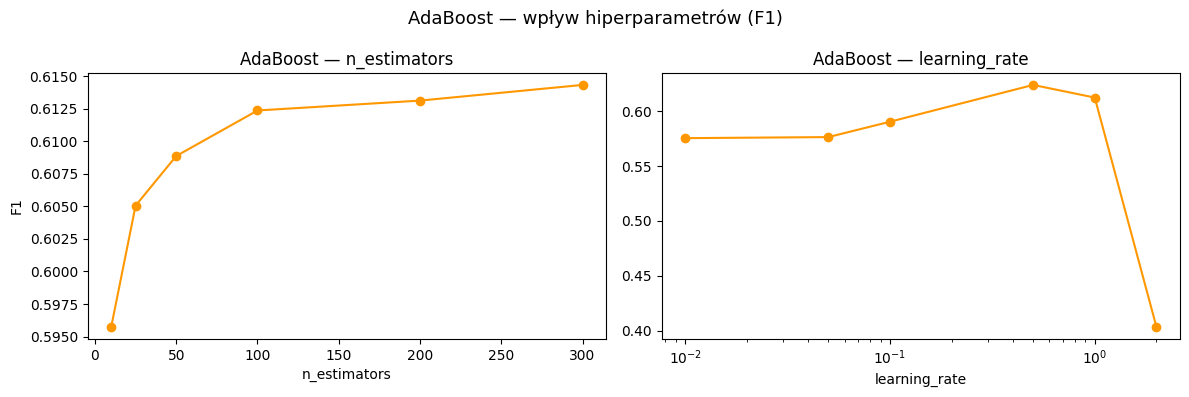

In [19]:
ab_nest = []
for n in n_estimators_vals:
    m = AdaBoostClassifier(n_estimators=n)
    m.fit(X_train, y_train)
    ab_nest.append(f1_score(y_test, m.predict(X_test)))

lr_vals = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
ab_lr = []
for lr in lr_vals:
    m = AdaBoostClassifier(n_estimators=100, learning_rate=lr)
    m.fit(X_train, y_train)
    ab_lr.append(f1_score(y_test, m.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_estimators_vals, ab_nest, marker="o", color="#FF9800")
axes[0].set_title("AdaBoost — n_estimators")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("F1")

axes[1].plot(lr_vals, ab_lr, marker="o", color="#FF9800")
axes[1].set_title("AdaBoost — learning_rate")
axes[1].set_xlabel("learning_rate")
axes[1].set_xscale("log")

plt.suptitle("AdaBoost — wpływ hiperparametrów (F1)", fontsize=13)
plt.tight_layout()
plt.show()

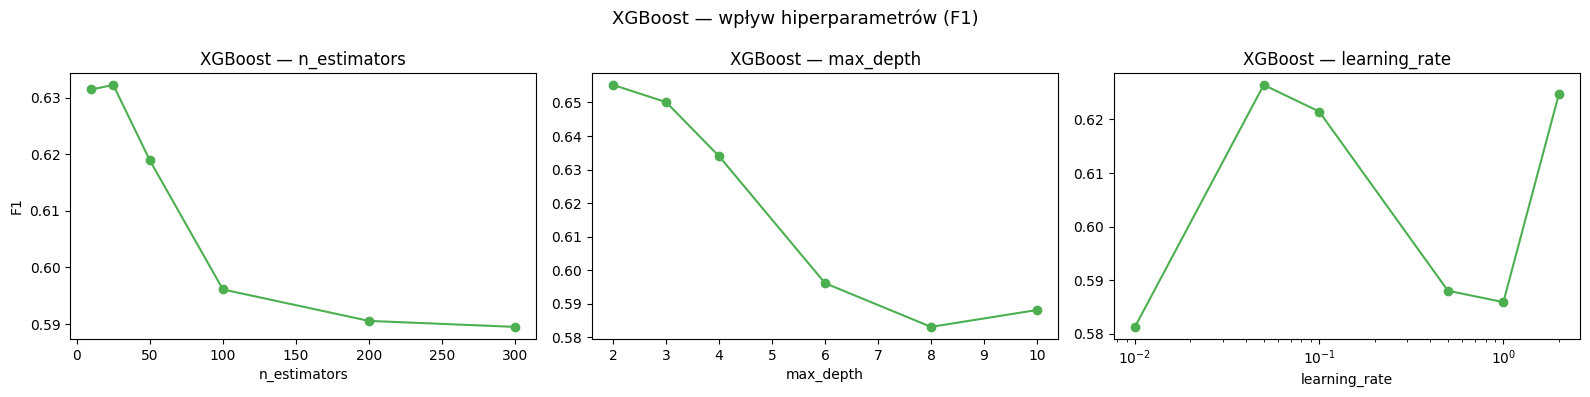

In [20]:

xgb_nest = []
for n in n_estimators_vals:
    m = XGBClassifier(n_estimators=n, verbosity=0, eval_metric="logloss")
    m.fit(X_train, y_train)
    xgb_nest.append(f1_score(y_test, m.predict(X_test)))

xgb_depth = []
depth_vals = [2, 3, 4, 6, 8, 10]
for d in depth_vals:
    m = XGBClassifier(n_estimators=100, max_depth=d, verbosity=0, eval_metric="logloss")
    m.fit(X_train, y_train)
    xgb_depth.append(f1_score(y_test, m.predict(X_test)))

xgb_lr = []
for lr in lr_vals:
    m = XGBClassifier(n_estimators=100, learning_rate=lr, verbosity=0, eval_metric="logloss")
    m.fit(X_train, y_train)
    xgb_lr.append(f1_score(y_test, m.predict(X_test)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(n_estimators_vals, xgb_nest, marker="o", color="#4CAF50")
axes[0].set_title("XGBoost — n_estimators")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("F1")

axes[1].plot(depth_vals, xgb_depth, marker="o", color="#4CAF50")
axes[1].set_title("XGBoost — max_depth")
axes[1].set_xlabel("max_depth")

axes[2].plot(lr_vals, xgb_lr, marker="o", color="#4CAF50")
axes[2].set_title("XGBoost — learning_rate")
axes[2].set_xlabel("learning_rate")
axes[2].set_xscale("log")

plt.suptitle("XGBoost — wpływ hiperparametrów (F1)", fontsize=13)
plt.tight_layout()
plt.show()

___


In [23]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay
import shap

best_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5),
    "AdaBoost":      AdaBoostClassifier(n_estimators=100, learning_rate=0.5),
    "XGBoost":       XGBClassifier(n_estimators=100, max_depth=2, verbosity=0, eval_metric="logloss"),
}

for name, model in best_models.items():
    model.fit(X_train, y_train)

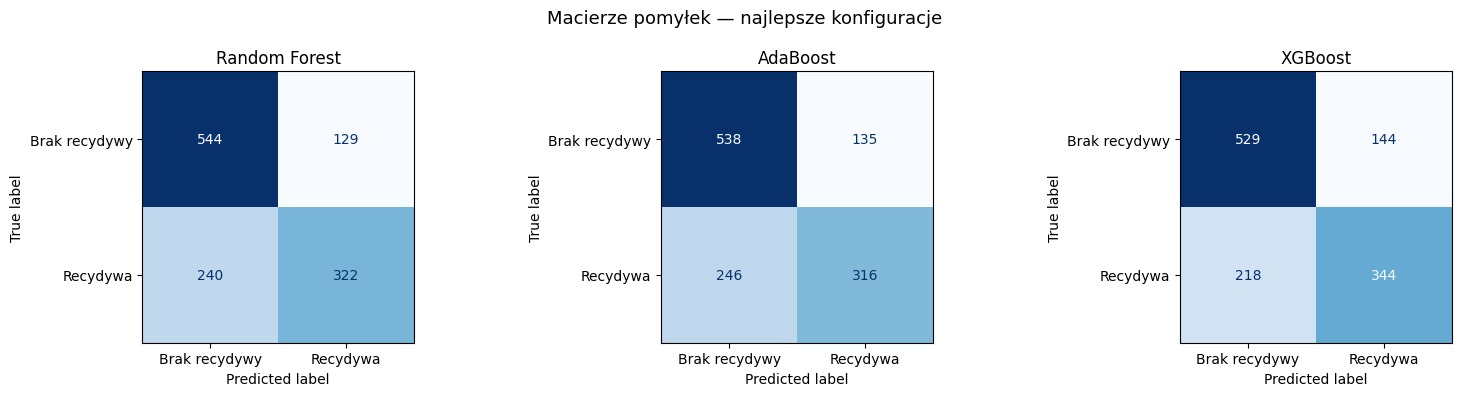

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, best_models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, model.predict(X_test),
        display_labels=["Brak recydywy", "Recydywa"],
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name)

plt.suptitle("Macierze pomyłek — najlepsze konfiguracje", fontsize=13)
plt.tight_layout()
plt.show()

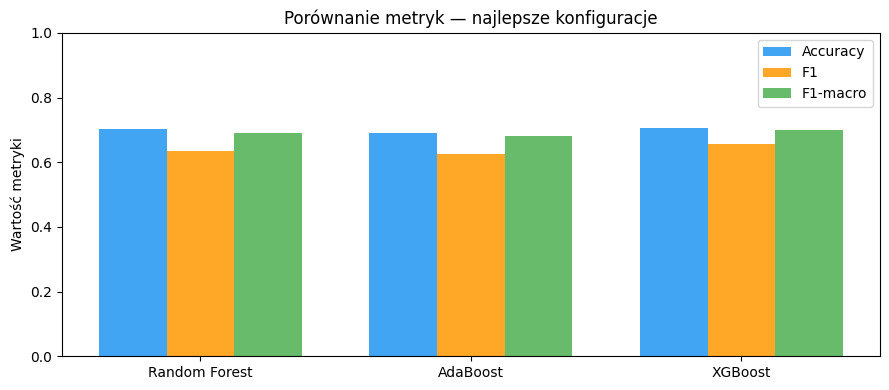

In [25]:
metrics = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    metrics[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "F1-macro":  f1_score(y_test, y_pred, average="macro"),
    }

metrics_df = pd.DataFrame(metrics).T

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(metrics_df))
width = 0.25
colors = ["#2196F3", "#FF9800", "#4CAF50"]

for i, col in enumerate(metrics_df.columns):
    ax.bar(x + i * width, metrics_df[col], width, label=col, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_df.index)
ax.set_ylabel("Wartość metryki")
ax.set_title("Porównanie metryk — najlepsze konfiguracje")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

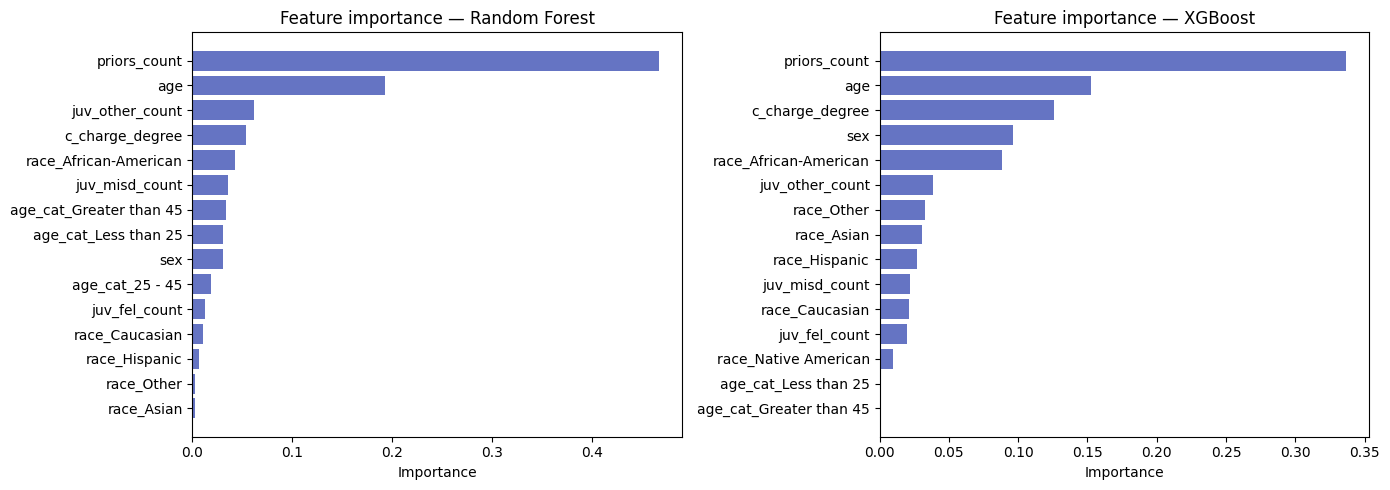

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, {k: v for k, v in best_models.items() if k != "AdaBoost"}.items()):
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(15)
    ax.barh(imp.index, imp.values, color="#3F51B5", alpha=0.8)
    ax.set_title(f"Feature importance — {name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

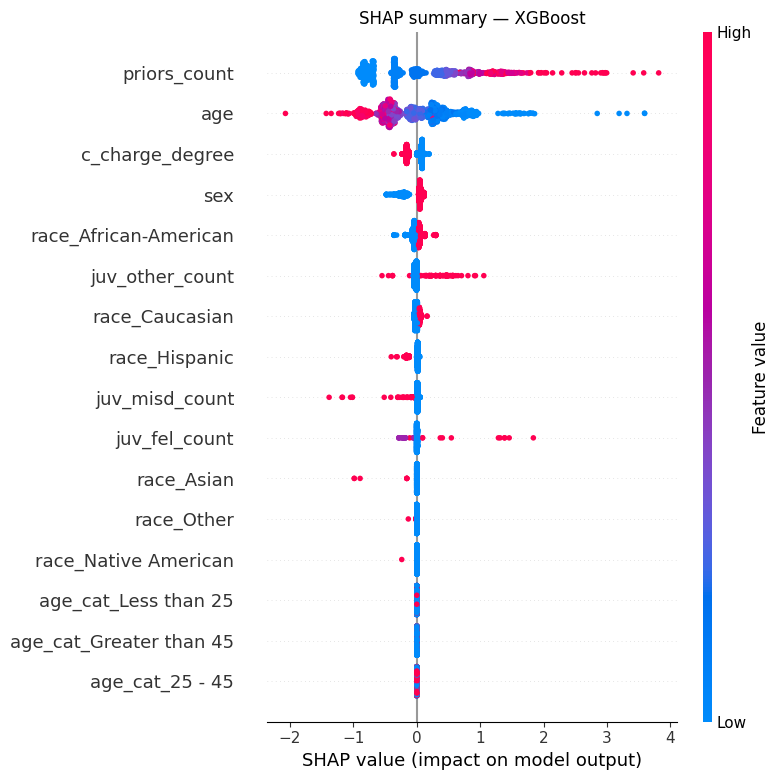

In [27]:
explainer = shap.TreeExplainer(best_models["XGBoost"])
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title("SHAP summary — XGBoost")
plt.tight_layout()
plt.show()

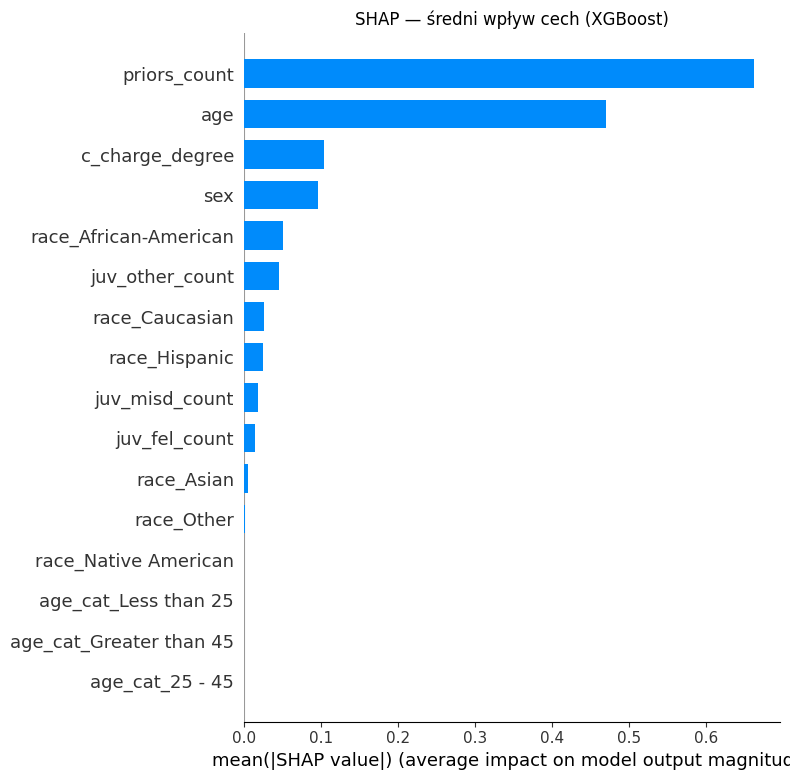

In [28]:
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type="bar", show=False)
plt.title("SHAP — średni wpływ cech (XGBoost)")
plt.tight_layout()
plt.show()

___

In [29]:
from sklearn.model_selection import train_test_split

# baseline — oryginalny X_test
y_pred_baseline = best_models["XGBoost"].predict(X_test)

# kolumny race i sex w df_model
race_cols = [c for c in df_model.columns if c.startswith("race_")]
sex_col_idx = feature_cols.index("sex")
race_col_indices = {c: feature_cols.index(c) for c in race_cols}

In [30]:
# eksperyment 1 — zmiana płci na przeciwną
X_test_flipped_sex = X_test.copy()
X_test_flipped_sex[:, sex_col_idx] = 1 - X_test_flipped_sex[:, sex_col_idx]

y_pred_flipped_sex = best_models["XGBoost"].predict(X_test_flipped_sex)

changed_sex = (y_pred_baseline != y_pred_flipped_sex).mean()
print(f"Zmiana decyzji po zamianie płci: {changed_sex:.1%}")

Zmiana decyzji po zamianie płci: 10.5%


In [31]:
# eksperyment 2 — wszyscy jako African-American vs wszyscy jako Caucasian
def set_race(X, race_col):
    X_new = X.copy()
    for c in race_col_indices:
        X_new[:, race_col_indices[c]] = 0
    if race_col in race_col_indices:
        X_new[:, race_col_indices[race_col]] = 1
    return X_new

X_as_black = set_race(X_test, "race_African-American")
X_as_white = set_race(X_test, "race_Caucasian")

y_pred_black = best_models["XGBoost"].predict(X_as_black)
y_pred_white = best_models["XGBoost"].predict(X_as_white)

print(f"Przewidywana recydywa gdy wszyscy = African-American: {y_pred_black.mean():.1%}")
print(f"Przewidywana recydywa gdy wszyscy = Caucasian:        {y_pred_white.mean():.1%}")

Przewidywana recydywa gdy wszyscy = African-American: 41.5%
Przewidywana recydywa gdy wszyscy = Caucasian:        37.5%


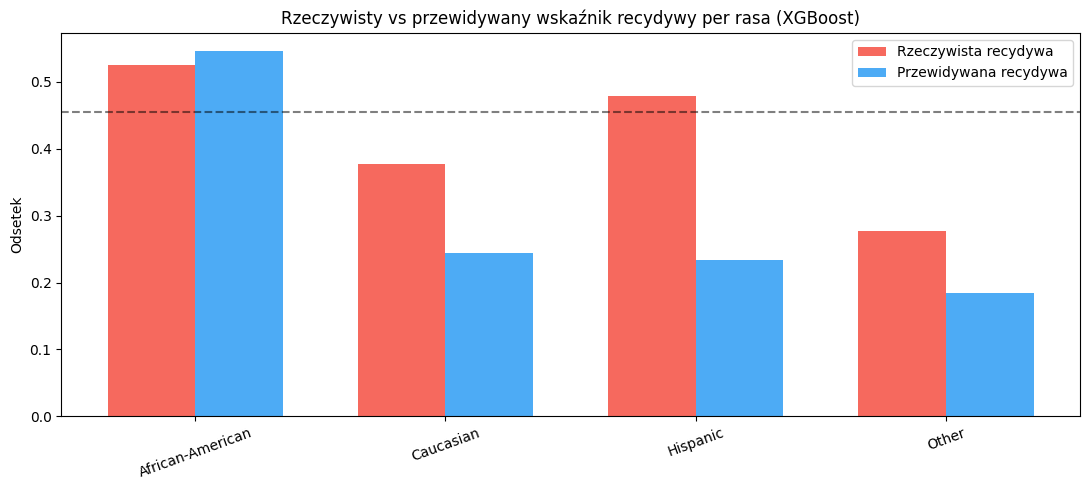

In [32]:
# wizualizacja — wskaźnik recydywy per rasa (rzeczywisty vs przewidywany)
race_recid_real = {}
race_recid_pred = {}

for race in ["African-American", "Caucasian", "Hispanic", "Other", "Asian", "Native American"]:
    col = f"race_{race}"
    if col not in feature_cols:
        continue
    mask = X_test[:, race_col_indices[col]] == 1
    if mask.sum() < 10:
        continue
    race_recid_real[race] = y_test[mask].mean()
    race_recid_pred[race] = y_pred_baseline[mask].mean()

races = list(race_recid_real.keys())
x = np.arange(len(races))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, [race_recid_real[r] for r in races], width, label="Rzeczywista recydywa", color="#F44336", alpha=0.8)
ax.bar(x + width/2, [race_recid_pred[r] for r in races], width, label="Przewidywana recydywa", color="#2196F3", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(races, rotation=20)
ax.set_ylabel("Odsetek")
ax.set_title("Rzeczywisty vs przewidywany wskaźnik recydywy per rasa (XGBoost)")
ax.legend()
ax.axhline(y_test.mean(), color="black", linestyle="--", alpha=0.5, label="średnia")
plt.tight_layout()
plt.show()

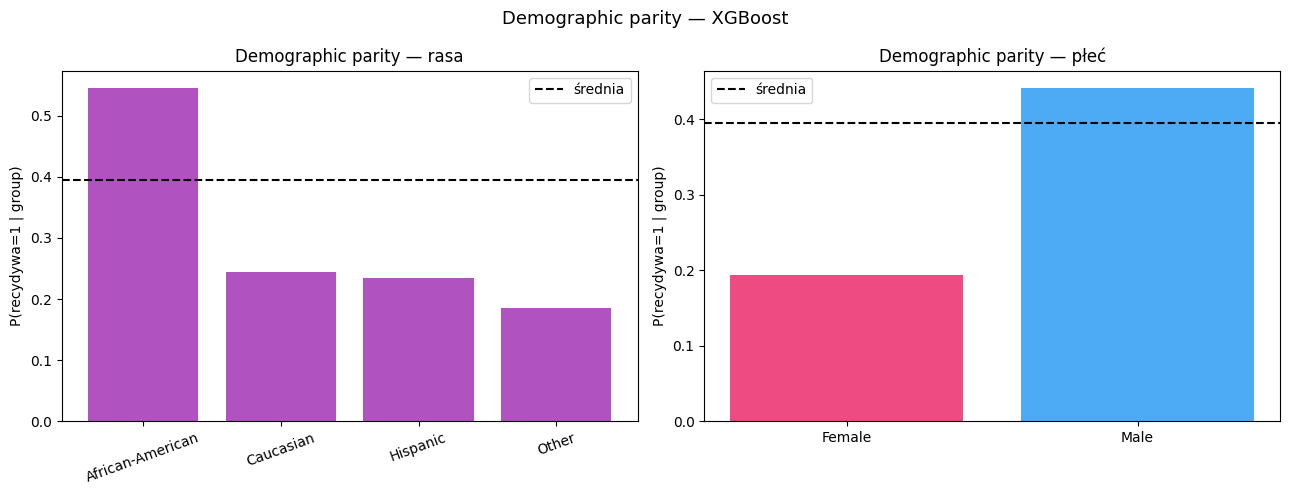

In [33]:
# demographic parity — różnica między grupami
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# per rasa
ax = axes[0]
pred_rates_race = pd.Series(race_recid_pred).sort_values(ascending=False)
ax.bar(pred_rates_race.index, pred_rates_race.values, color="#9C27B0", alpha=0.8)
ax.axhline(y_pred_baseline.mean(), color="black", linestyle="--", label="średnia")
ax.set_title("Demographic parity — rasa")
ax.set_ylabel("P(recydywa=1 | group)")
ax.tick_params(axis="x", rotation=20)
ax.legend()

# per płeć
ax = axes[1]
for sex_val, label, color in [(0, "Female", "#E91E63"), (1, "Male", "#2196F3")]:
    mask = X_test[:, sex_col_idx] == sex_val
    rate = y_pred_baseline[mask].mean()
    ax.bar(label, rate, color=color, alpha=0.8)
ax.axhline(y_pred_baseline.mean(), color="black", linestyle="--", label="średnia")
ax.set_title("Demographic parity — płeć")
ax.set_ylabel("P(recydywa=1 | group)")
ax.legend()

plt.suptitle("Demographic parity — XGBoost", fontsize=13)
plt.tight_layout()
plt.show()

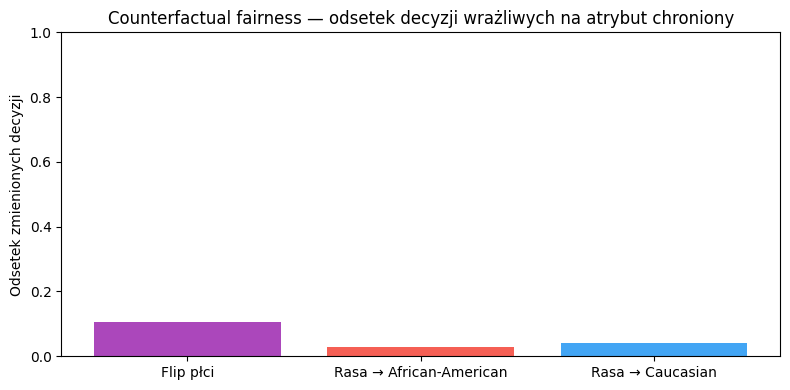

In [34]:
# counterfactual — ile osób zmieniło decyzję po flipie płci i rasy
results_cf = {
    "Flip płci":               (y_pred_baseline != y_pred_flipped_sex).mean(),
    "Rasa → African-American": (y_pred_baseline != y_pred_black).mean(),
    "Rasa → Caucasian":        (y_pred_baseline != y_pred_white).mean(),
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results_cf.keys(), results_cf.values(), color=["#9C27B0", "#F44336", "#2196F3"], alpha=0.85)
ax.set_ylabel("Odsetek zmienionych decyzji")
ax.set_title("Counterfactual fairness — odsetek decyzji wrażliwych na atrybut chroniony")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()